In [1]:
#lOAD PACKAGES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#LOAD DATA
imb=pd.read_csv('random_demand.csv')
er=pd.read_csv('Energy reserve.csv')
r=pd.read_csv('Reserve.csv')

In [5]:
#quality control energy reserves diagonal equal to reserves -- UP direction
sum(r['reserve_up_MW'].values-er['reserve_up_MW'].loc[er['i_hour']==er['t_hour']].values)

0.0

In [7]:
#quality control energy reserves diagonal equal to reserves -- DN direction
sum(r['reserve_down_MW'].values-er['reserve_down_MW'].loc[er['i_hour']==er['t_hour']].values)

0.0

In [9]:
#function for energy reserves up that corresoinds to ESA report
def energy_reserves_per_day(imb_day):
    imb=imb_day #columns 3 and after scenarios; rows hours of the day
    er=pd.DataFrame(np.zeros((24,24)))
    for t in range(1,25): #read all hours of the day
        for i in range(1,t+1): #go over i<=t
            er.at[i-1,t-1]=np.percentile(imb[imb.columns[3:]].iloc[i-1:t].sum(axis=0),97.5)-imb['demand'].iloc[i-1:t].sum(axis=0)
    return er


In [15]:
def energy_reserves_per_dayv2(imb_day): #This function limits energy reserves to sum of power reserves from i  to t
    imb=imb_day #columns 3 and after scenarios; rows hours of the day
    er=pd.DataFrame(np.zeros((24,24)))
    for t in range(1,25): #read all hours of the day
        for i in range(1,t+1): #go over i<=t
            er.at[i-1,t-1]=np.percentile(imb[imb.columns[3:]].iloc[i-1:t].sum(axis=0),97.5)-imb['demand'].iloc[i-1:t].sum(axis=0)
    #quality control with diagonal
    for t in range(1,25): #read all hours of the day
        for i in range(1,t+1): #go over i<=t
           if i!=t:
             er.at[i-1,t-1]=min(er.at[i-1,t-1],np.trace(er[er.columns[i-1:t]].iloc[i-1:t]))     #trace gives you the sum of diagonal elements                  
                               
    return er


In [19]:
test=energy_reserves_per_day(imb.iloc[144:168]) #test has ER with ESA method
test2=energy_reserves_per_dayv2(imb.iloc[144:168]) #test2 has ER for day 7 with modified input

In [21]:
#quality control: Compare ES calculations vs PG calculations for day 7
diff=[]
for t in range(0,24):
    for i in range(0,t+1):
        #HARDCODED 145 because I check for just day 7
       diff.append( test.at[i,t]-(er['reserve_up_MW'].loc[(er['i_hour']==145+i) & (er['t_hour']==145+t)].values)[0])



Text(0.5, 1.0, 'Day 7')

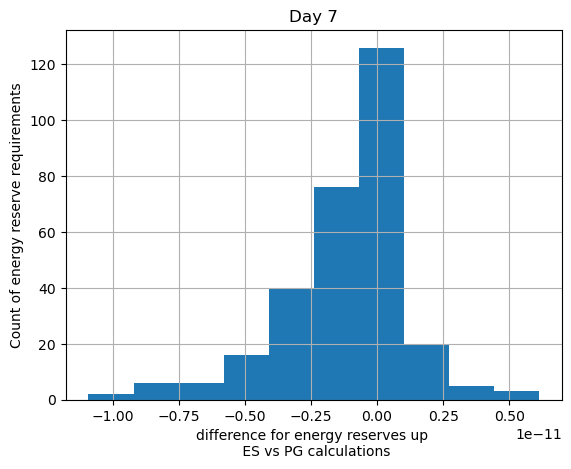

In [23]:
#differences are 0 for ES vs PG calculations
pd.DataFrame(diff).hist()
plt.xlabel('difference for energy reserves up \n ES vs PG calculations')
plt.ylabel('Count of energy reserve requirements')
plt.title('Day 7')

In [25]:
#quality control: is the sum of r higher than er? QC should take negative values
QC=[]
for t in range(0,24):
    for i in range(0,t+1):
       QC.append( test.at[i,t]-r['reserve_up_MW'].loc[(r['hour']>=i+145) & (r['hour']<=t+145)].sum())



Text(0.5, 1.0, 'Day 7')

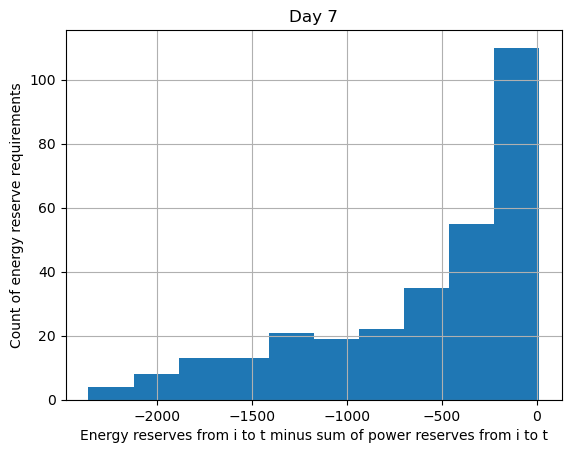

In [27]:
pd.DataFrame(QC).hist()
plt.xlabel('Energy reserves from i to t minus sum of power reserves from i to t')
plt.ylabel('Count of energy reserve requirements')
plt.title('Day 7')

In [29]:
max(QC) #this gives the max QC; when positive wrong

12.31317514999921

In [31]:
#quality control: is the sum of r higher than er? QC should take negative values
QC2=[]
for t in range(0,24):
    for i in range(0,t+1):
       QC2.append( test2.at[i,t]-r['reserve_up_MW'].loc[(r['hour']>=i+145) & (r['hour']<=t+145)].sum())



Text(0.5, 1.0, 'Day 7 - revised calculations for energy reserves')

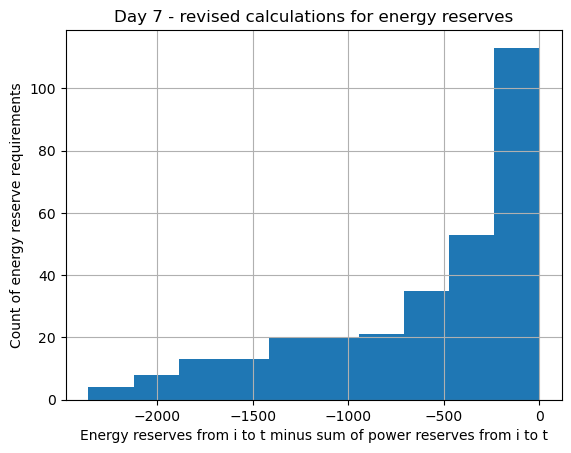

In [33]:
pd.DataFrame(QC2).hist()
plt.xlabel('Energy reserves from i to t minus sum of power reserves from i to t')
plt.ylabel('Count of energy reserve requirements')
plt.title('Day 7 - revised calculations for energy reserves')

In [35]:
max(QC2)

1.1368683772161603e-13

In [37]:
#quality control: Compare ES calculations vs PG calculations for day 7
diff2=[]
for t in range(0,24):
    for i in range(0,t+1):
        #HARDCODED 145 because I check for just day 7
       diff2.append( test2.at[i,t]-(er['reserve_up_MW'].loc[(er['i_hour']==145+i) & (er['t_hour']==145+t)].values)[0])

Text(0.5, 1.0, 'Day 7')

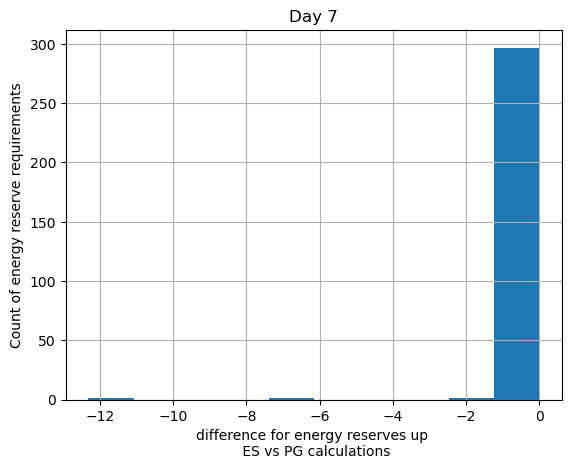

In [39]:
#differences are 0 for ESv2 vs PG calculations
pd.DataFrame(diff2).hist()
plt.xlabel('difference for energy reserves up \n ES vs PG calculations')
plt.ylabel('Count of energy reserve requirements')
plt.title('Day 7')